Original equation: y = -4.296894263819517 * x + -1.0465004814731387 + error
Your Method:  m = -4.383788184421513 b = -1.0493472386620817
NumPy Method: m = -4.383788184421508 b = -1.0493472386620855
Smallest error: 0.01966622028416176 at point ( 0.09 , -1.4242219549758561 )
Largest error: 1.0699696323144465 at point ( 0.78 , -3.3987323901964146 )


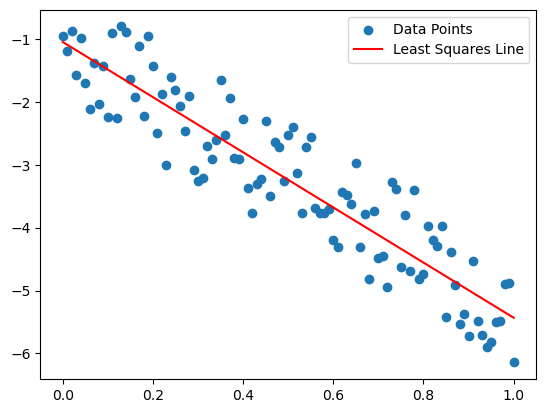

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def least_squares(x, y):
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x[i] * y[i] for i in range(n))
    sum_x2 = sum(x[i] ** 2   for i in range(n))
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    c = (sum_y - m * sum_x) / n
    return m, c

X = np.sort(np.arange(0, 1.01, 0.01))
m_rand = np.random.uniform(-10, 10)
b_rand = np.random.uniform(-10, 10)

print("Original equation: y =", m_rand, "* x +", b_rand, "+ error")
error = np.random.uniform(-1, 1, len(X))
Y = (m_rand * X) + b_rand + error

m_custom, b_custom = least_squares(X, Y)
m_np, b_np = np.polyfit(X, Y, 1)

print("Your Method:  m =", m_custom, "b =", b_custom)
print("NumPy Method: m =", m_np, "b =", b_np)
Y_pred = m_custom * X + b_custom
residuals = abs(Y - Y_pred)

min_idx = np.argmin(residuals)
max_idx = np.argmax(residuals)

print("Smallest error:", residuals[min_idx], "at point (", X[min_idx], ",", Y[min_idx], ")")
print("Largest error:",  residuals[max_idx], "at point (", X[max_idx], ",", Y[max_idx], ")")
plt.scatter(X, Y, label="Data Points")
plt.plot(X, Y_pred, 'r', label="Least Squares Line")
plt.legend()
plt.show()